In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as sl
from numpy import nan,inf
import scipy.constants as sc
import scipy.interpolate as si
import matplotlib as mpl
import glob
from astropy.time import Time
np.set_printoptions(precision=10)
import matplotlib
plt.rc('font',**{'family':'serif','serif':['Times']})
mpl.rcParams['font.size'] = 13
#mpl.rcParams['font.family'] = 'serif'
#mpl.rcParams['font.sans-serif'] = ['DejaVu Sans']
mpl.rcParams['axes.linewidth'] = 1
mpl.rcParams['lines.linewidth'] = 2.5
mpl.rcParams['patch.linewidth'] = 1

# Changing this will affect the size of the plot in Jupyter notebook as well as resolution of the final PDF. Can change later
plt.rcParams['figure.dpi'] = 100

#mpl.rcParams['mathtext.fontset'] = 'custom'
#mpl.rcParams['mathtext.rm'] = 'Serif'
#mpl.rcParams['mathtext.it'] = 'Serif:italic'
#mpl.rcParams['mathtext.bf'] = 'Serif:bold'

# tick parameters:
mpl.rcParams['xtick.top'] = True
mpl.rcParams['ytick.right'] = True


mpl.rcParams['xtick.minor.visible'] = True
mpl.rcParams['ytick.minor.visible'] = True
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['xtick.direction'] = 'in'
    
mpl.rcParams['xtick.major.size'] = 6  # default 3.5
mpl.rcParams['ytick.major.size'] = 6  # default 3.5
mpl.rcParams['xtick.minor.size'] =  3  # default 2 
mpl.rcParams['ytick.minor.size'] = 3  # default 2 
    
mpl.rcParams['xtick.major.width'] = 1  # default 0.8
mpl.rcParams['ytick.major.width'] = 1  # default 0.8
mpl.rcParams['xtick.minor.width'] =1  # default 0.6
mpl.rcParams['ytick.minor.width'] = 1  # default 0.6
#mpl.rcParams['text.usetex'] = True


MASS_TO_FREQ = sc.eV / sc.h
def plot_timescales( ax,ymin,ymax,annotate=True):

    l10ma_T = np.log10( 1/(1.0*sc.day*1 * MASS_TO_FREQ) )
    ax.plot([l10ma_T,l10ma_T],[ymin,ymax],'gray',ls=":",lw=1)
    if annotate==True:
        ax.annotate(r"1 day",xy = [l10ma_T,ymax],va = "top",rotation=-90,color="dimgray")
    
    # l10ma_T = np.log10( 1/(1.0*sc.day*14 * MASS_TO_FREQ) )
    # ax.plot([l10ma_T,l10ma_T],[ymin,ymax],'gray',ls="-")
    # if annotate==True:
    #     ax.annotate(r"2 weeks",xy = [l10ma_T,ymax],va = "top",rotation=-90,color="dimgray")

    l10ma_T = np.log10( 1/(1.0*sc.year * MASS_TO_FREQ) )
    ax.plot([l10ma_T,l10ma_T],[ymin,ymax],'gray',ls=":",lw=1)
    if annotate==True:
        ax.annotate(r"1 year",xy = [l10ma_T,ymax],va = "top",rotation=-90,color="dimgray")

    l10ma_T = np.log10( 1/(11.0*sc.year * MASS_TO_FREQ) )
    ax.plot([l10ma_T ,l10ma_T ],[ymin,ymax],'gray',ls=":",lw=1)
    if annotate==True:
        ax.annotate(r"Solar Cycle",xy = [l10ma_T ,ymax],va = "top",rotation=-90,color="dimgray")

    l10ma_T = np.log10( 1/(18.0*sc.year * MASS_TO_FREQ) )
    ax.plot([l10ma_T,l10ma_T],[ymin,ymax],'gray',ls="-",lw=1)
    if annotate==True:
        ax.annotate(r"T$_{\rm obs}$",xy = [l10ma_T,ymax],va = "top",rotation=-90,color="dimgray")


#rho = 7.68351e-6 * 0.40 #0.46
rho = (0.4 * 1e9 * 100**3) * sc.c**3  * sc.hbar**3 / sc.eV**3
l10S_to_l10ga = lambda l10S,l10ma: l10S+9+l10ma-np.log10(rho)/2


def make_ul_plot(ax,l10ma , ul_auto,ul_full ):
    try:
        ax.plot(l10ma ,l10S_to_l10ga(ul_auto,l10ma),'.',color='b')
        ax.plot(l10ma ,l10S_to_l10ga(ul_auto,l10ma),'-',color='b',label="Auto-corr")
    except:
        pass

    
    try:
        ax.plot(l10ma ,l10S_to_l10ga(ul_full,l10ma),'.',color='r')
        ax.plot(l10ma ,l10S_to_l10ga(ul_full,l10ma),'-',color='r',label="Full-corr")
    except:
        pass






    ax.set_xlim(-23.5,-18.5)
    ymin = -16
    ymax = -8
    ax.set_ylim(ymin,ymax)
    #plt.title(r"the 95% upper limit on $\log_{\rm 10}g_{a\gamma\gamma}/{\rm GeV}^{-1}$"+
    #          "\n assuming local DM density " + r"$0.40 {\rm GeV}/{\rm cm}^3$")

    ax.legend(loc="lower right",prop={'size': 10})

    plot_timescales( ax,ymin,ymax,annotate=True)


    #ax.plot(mock[:,0] , l10S_to_l10ga(mock[:,2],mock[:,0]),'red' )

    #plot_timescales(ax,ymin,ymax)

    ax.set_xlabel(r"$\log_{\rm 10}m_a /{\rm eV}$")
    ax.set_ylabel(r"$\log_{\rm 10}g_{a\gamma\gamma}/{\rm GeV}^{-1}$")
    ax.grid(axis="y")


def make_bf_plot(ax,l10ma,lbf_af,lbf_nf):

    #fig , ax = plt.subplots(figsize=(5,3))
    ymin = min( [np.nanmin(lbf_nf) , np.nanmin(lbf_af) ,-10]  )
    ymax = max( [np.nanmax(lbf_nf)*1.2 , np.nanmax(lbf_af)*1.2 , 15 ] )
    plot_timescales( ax,ymin,ymax,annotate=False)

    try:
        lbf_nf[lbf_nf==inf]=ymax
        lbf_nf[lbf_nf==-inf]=ymin
        ax.plot(l10ma,lbf_nf,'-',color='r',label="Full vs Null")
        ax.plot(l10ma,lbf_nf,'.',color='r')
    except:
        pass

    try:
        lbf_af[lbf_af==inf]=ymax
        lbf_af[lbf_af==-inf]=ymin
        ax.plot(l10ma,lbf_af,'-',color='k',label="Full vs Auto")
        ax.plot(l10ma,lbf_af,'.',color='k')
    except:
        pass
    
    
    ax.set_ylim(ymin,ymax)
    ax.set_xlim(-23.5,-18.5)
    ax.plot([-23.5,-18.5],[0,0],lw=2,color="black")


    ax.set_xlabel(r"$\log_{\rm 10}m_a /{\rm eV}$")
    #ax.set_ylabel(r"$\ln $BF$^{\rm full}_{\rm auto}$")
    ax.set_ylabel(r"$\ln $BF")
    ax.grid(axis="y")
    ax.legend(loc="upper right",prop={'size': 10})

def show_signal(ax,TOAs,aldms,multiplier = 1):
    mins = []
    maxs = []
    for i in range(22):
        ax.plot(TOAs[i][0],aldms[i][0]*multiplier/np.pi*180,"black",lw=1)
        mins = np.min(TOAs[i][0])
        maxs = np.max(TOAs[i][0])
    ax.set_xlim( np.min(mins) ,np.max(maxs))
    ax.set_ylabel(r"$\Delta PA^a(t) ({\rm deg})$")
    ax.annotate(r"$\Delta T = %.1f$ years"%((np.max(maxs)-np.max(mins))/sc.year) ,xy=(0.98,0.91),xycoords="axes fraction",va = "top",ha='right',bbox=dict(boxstyle="round",
                      fc="white", ec="black",alpha=0.7))
                

In [2]:
# crit = np.where(lbf_nf>20)[0]
# np.array([crit,l10ma[crit],lbf_nf[crit]]).T
# for c in crit:
#     print(c,l10ma[c])


# Red | seed:60

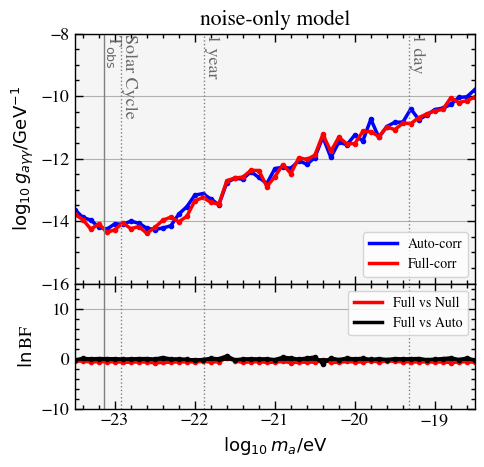

In [3]:
# True
fig,axes = plt.subplots(2,1,figsize=(5,5),gridspec_kw={'height_ratios': [4, 2]})
lbf_nf = None; lbf_af = None; ul_auto= None; ul_full=None;
plt.subplots_adjust(left=0.15,
                    bottom=0.10, 
                    right=0.95, 
                    top=0.85, 
                    wspace=0.0, 
                    hspace=0.0)

# TOAs ,aldm = np.load("aldm_example_-23.0.npy",allow_pickle=True)

# axes[0].set_title("White and Red noises injected")
# axes[0].set_xticks([])
# show_signal(axes[0] , TOAs,aldm,multiplier=0)
# axes[0].set_facecolor('whitesmoke')

l10ma = np.arange(0,51)*0.1 -23.5


ul_auto = np.array([-1.892, -2.238, -2.426, -2.748, -2.917, -2.844, -2.961, -2.958,
       -3.126, -3.384, -3.528, -3.576, -3.606, -3.329, -3.196, -2.925,
       -2.977, -3.25 , -3.533, -2.922, -2.889, -3.012, -2.875, -3.158,
       -3.458, -3.079, -3.127, -3.271, -3.119, -3.341, -3.222, -2.666,
       -3.421, -3.032, -3.213, -3.004, -3.291, -2.697, -3.378, -3.13 ,
       -3.094, -3.19 , -2.867, -3.308, -3.262, -3.187, -3.243, -3.224,
       -3.098, -3.18 , -3.048])


ul_full = np.array([-2.041, -2.307, -2.713, -2.645, -3.018, -3.033, -2.912, -3.2  ,
       -3.23 , -3.547, -3.46 , -3.328, -3.33 , -3.58 , -3.503, -3.109,
       -3.101, -3.354, -3.518, -2.864, -2.875, -2.95 , -2.832, -2.938,
       -3.55 , -3.341, -3.048, -3.435, -3.03 , -3.185, -3.149, -2.585,
       -3.223, -2.872, -3.185, -3.275, -2.989, -3.09 , -3.352, -3.144,
       -3.33 , -3.221, -3.337, -3.246, -3.225, -3.23 , -3.283, -3.01 ,
       -3.266, -3.3  , -3.293])



make_ul_plot(axes[0],l10ma,ul_auto,ul_full)
axes[0].set_title("noise-only model")
axes[0].set_facecolor('whitesmoke')
#axes[0].set_title("White/Red noise injected (also search for red noise)\n 22 pulsars, 10cm band,"+r" $\psi_{0,1,2}$")
#axes[0].plot(l10ma , -13-2*(l10ma+23.5),':')
 

lbf_af = np.array([-0.259,  0.031, -0.05 , -0.003, -0.02 , -0.035, -0.08 , -0.057,
       -0.013, -0.007, -0.094,  0.21 , -0.079, -0.058, -0.145, -0.32 ,
       -0.188,  0.04 , -0.045,  0.525, -0.257, -0.078, -0.043, -0.066,
       -0.046, -0.21 ,  0.264,  0.106, -0.116,  0.102,  0.296, -1.048,
        0.1  , -0.199,  0.074, -0.069,  0.062, -0.178, -0.028, -0.184,
       -0.018, -0.055, -0.037,  0.007, -0.219, -0.119, -0.007,  0.135,
       -0.19 ,  0.09 , -0.293])



lbf_nf = np.array([-0.546, -0.482, -0.682, -0.602, -0.635, -0.631, -0.717, -0.727,
       -0.654, -0.691, -0.842, -0.781, -0.716, -0.649, -0.648, -0.67 ,
       -0.545, -0.68 , -0.624,  0.096, -0.431, -0.764, -0.65 , -0.593,
       -0.758, -0.716, -0.576, -0.794, -0.732, -0.698, -0.71 , -0.265,
       -0.737, -0.762, -0.572, -0.676, -0.671, -0.422, -0.679, -0.478,
       -0.549, -0.627, -0.66 , -0.662, -0.659, -0.702, -0.662, -0.801,
       -0.691, -0.618, -0.741])


axes[1].set_facecolor('whitesmoke')
make_bf_plot(axes[1],l10ma,lbf_af,lbf_nf)
plt.savefig("mock_example_2.pdf",bbox_inches='tight')



# -23, -2.7 | seed:89

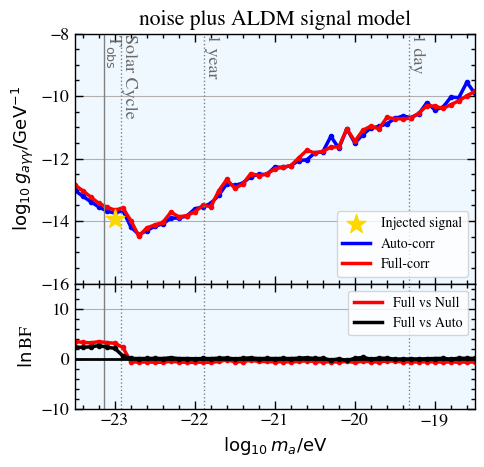

In [4]:
fig,axes = plt.subplots(2,1,figsize=(5,5),gridspec_kw={'height_ratios': [4, 2]})
lbf_nf = None; lbf_af = None; ul_auto= None; ul_full=None;
plt.subplots_adjust(left=0.15,
                    bottom=0.10, 
                    right=0.95, 
                    top=0.85, 
                    wspace=0.0, 
                    hspace=0.0)


l10ma = np.arange(0,51)*0.1 -23.5


ul_auto = np.array([-1.269, -1.563, -1.837, -2.103, -2.336, -2.501, -2.515, -3.142,
       -3.489, -3.461, -3.423, -3.443, -3.369, -3.452, -3.495, -3.365,
       -3.4  , -3.387, -3.227, -2.962, -3.116, -3.139, -3.031, -3.063,
       -3.163, -3.026, -3.14 , -3.181, -3.118, -3.197, -3.073, -3.138,
       -2.745, -3.227, -2.707, -3.258, -3.087, -2.977, -3.029, -3.047,
       -2.973, -2.995, -3.145, -3.121, -2.868, -3.195, -3.218, -2.991,
       -3.105, -2.713, -3.17 ])

ul_full = np.array([-1.097, -1.385, -1.688, -1.988, -2.21 , -2.405, -2.436, -2.941,
       -3.535, -3.374, -3.379, -3.399, -3.173, -3.416, -3.484, -3.459,
       -3.351, -3.492, -3.084, -2.821, -3.21 , -3.168, -2.935, -3.102,
       -3.149, -3.087, -3.131, -3.183, -3.03 , -2.892, -3.076, -3.127,
       -3.087, -3.182, -2.705, -3.2  , -2.952, -2.917, -3.107, -2.841,
       -2.979, -3.085, -3.163, -3.105, -2.963, -3.079, -3.252, -3.231,
       -3.207, -3.146, -3.106])

axes[0].set_title("noise plus ALDM signal model")
axes[0].scatter(-23,l10S_to_l10ga(-2.7,-23),s=200,marker="*",color="gold",zorder=4,alpha=1,label="Injected signal")
axes[0].set_facecolor('aliceblue')
make_ul_plot(axes[0],l10ma,ul_auto,ul_full)
#axes[0].plot(l10ma , -13-2*(l10ma+23.5),':')
 

lbf_af = np.array([ 2.294e+00,  2.251e+00,  2.354e+00,  2.596e+00,  2.288e+00,
        2.044e+00,  5.288e-01,  4.083e-02,  4.254e-03,  1.689e-02,
        4.711e-02,  1.317e-02,  1.823e-01,  1.810e-03,  7.737e-03,
       -3.525e-02,  1.942e-02, -3.909e-03,  8.338e-02,  1.050e-01,
       -4.707e-02,  6.227e-02,  1.480e-01, -9.809e-04,  3.684e-02,
        2.438e-03,  4.088e-02, -2.282e-03,  8.752e-02,  1.646e-01,
        1.820e-02,  5.231e-02, -2.773e-01, -7.316e-02, -3.608e-01,
        4.382e-02,  2.356e-01, -9.215e-02,  6.151e-02,  7.337e-02,
       -1.054e-01, -7.160e-02, -6.645e-02, -7.458e-02, -2.423e-02,
        1.041e-02,  4.155e-02, -1.040e-01,  7.293e-02,  4.610e-02,
        4.135e-02])



lbf_nf = np.array([ 3.405,  3.249,  3.144,  3.391,  3.208,  3.055,  2.234, -0.633,
       -0.729, -0.654, -0.741, -0.722, -0.543, -0.681, -0.752, -0.748,
       -0.709, -0.776, -0.575, -0.276, -0.628, -0.613, -0.338, -0.582,
       -0.571, -0.657, -0.616, -0.668, -0.566, -0.436, -0.584, -0.653,
       -0.648, -0.685, -0.56 , -0.748, -0.518, -0.622, -0.693, -0.453,
       -0.526, -0.65 , -0.657, -0.678, -0.626, -0.656, -0.708, -0.661,
       -0.718, -0.685, -0.689])


axes[1].set_facecolor('aliceblue')
make_bf_plot(axes[1],l10ma,lbf_af,lbf_nf)
plt.savefig("mock_example_3.pdf",bbox_inches='tight')


# -21.0 | -2.75 | seed:72

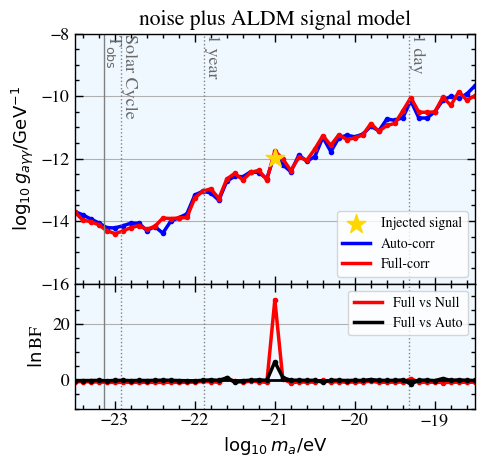

In [5]:
# True
fig,axes = plt.subplots(2,1,figsize=(5,5),gridspec_kw={'height_ratios': [4, 2]})
lbf_nf = None; lbf_af = None; ul_auto= None; ul_full=None;
plt.subplots_adjust(left=0.15,
                    bottom=0.10, 
                    right=0.95, 
                    top=0.85, 
                    wspace=0.0, 
                    hspace=0.0)


l10ma = np.arange(0,51)*0.1 -23.5


ul_auto = np.array([-1.953, -2.158, -2.39 , -2.616, -2.868, -2.975, -3.008, -3.023,
       -3.125, -3.46 , -3.433, -3.741, -3.457, -3.449, -3.427, -2.922,
       -2.9  , -3.059, -3.389, -2.878, -2.822, -2.938, -2.875, -3.007,
       -3.298, -2.597, -3.055, -3.378, -2.945, -3.241, -3.19 , -2.676,
       -3.233, -2.891, -2.91 , -3.059, -3.074, -2.92 , -3.168, -2.892,
       -3.031, -3.047, -2.606, -3.257, -3.36 , -3.257, -2.989, -2.968,
       -3.128, -3.087, -2.929])

ul_full = np.array([-1.965, -2.331, -2.473, -2.676, -2.967, -3.154, -3.178, -3.163,
       -3.204, -3.418, -3.425, -3.26 , -3.375, -3.457, -3.541, -3.015,
       -2.899, -2.924, -3.335, -2.809, -2.727, -3.041, -2.897, -2.933,
       -3.337, -2.515, -2.868, -3.341, -3.017, -3.207, -2.95 , -2.624,
       -3.031, -2.793, -3.048, -3.095, -3.1  , -2.834, -3.188, -3.093,
       -3.133, -2.827, -2.505, -3.072, -3.176, -3.262, -2.891, -3.253,
       -2.918, -3.287, -3.246])


axes[0].scatter(-21.0,l10S_to_l10ga(-2.75,-21.0),s=200,marker="*",color="gold",zorder=4,alpha=1,label="Injected signal")
axes[0].set_facecolor('aliceblue')
make_ul_plot(axes[0],l10ma,ul_auto,ul_full)
axes[0].set_title("noise plus ALDM signal model")
#axes[0].plot(l10ma , -13-2*(l10ma+23.5),':')
 

lbf_af = np.array([-7.887e-02, -8.205e-02,  -0.065, -8.126e-03, -1.733e-01,
       -2.276e-02, -5.484e-03, -1.030e-01, -3.355e-02, -6.640e-02,
       -1.112e-02,  0.054,  1.659e-02, -8.311e-02, -1.340e-01,
       -1.733e-01,  2.588e-02,  1.644e-01,  1.854e-03,  9.075e-01,
       -7.062e-01, -1.245e-01,  5.034e-02,  1.485e-01,  2.396e-02,
        6.540e+00,  9.581e-01,  2.985e-02,  6.235e-02, -3.160e-02,
        2.869e-02, -6.758e-01,  4.401e-02,  9.852e-03, -6.408e-02,
       -2.644e-03, -4.862e-02,  2.985e-01,  6.219e-03, -3.270e-02,
       -1.394e-02,  1.359e-01, -1.316e+00,  3.118e-02,  8.190e-02,
       -1.017e-01,  6.433e-01, -5.296e-03,  1.701e-01,  1.416e-02,
       -3.663e-02])





lbf_nf = np.array([-0.528, -0.424, -0.563, -0.559, -0.729, -0.724, -0.718, -0.682,
       -0.712, -0.705, -0.703, -0.734, -0.679, -0.733, -0.701, -0.627,
       -0.396, -0.482, -0.675,  0.834, -0.346, -0.672, -0.251, -0.473,
       -0.744,    np.log(0.6476)+29,  0.391, -0.837, -0.567, -0.645, -0.606, -0.027,
       -0.59 , -0.461, -0.704, -0.559, -0.603, -0.271, -0.706, -0.671,
       -0.64 , -0.6  ,  0.608, -0.662, -0.734, -0.616, -0.772, -0.692,
       -0.633, -0.712, -0.635])


axes[1].set_facecolor('aliceblue')
make_bf_plot(axes[1],l10ma,lbf_af,lbf_nf)
plt.savefig("mock_example_5.pdf",bbox_inches='tight')


In [6]:
# crit = np.where(lbf_af>5)[0]
# np.array([crit,l10ma[crit],lbf_nf[crit]]).T
# for c in crit:
#     print(c,l10ma[c])

# Mock data posterior

(2657, 112)
(1775, 112)


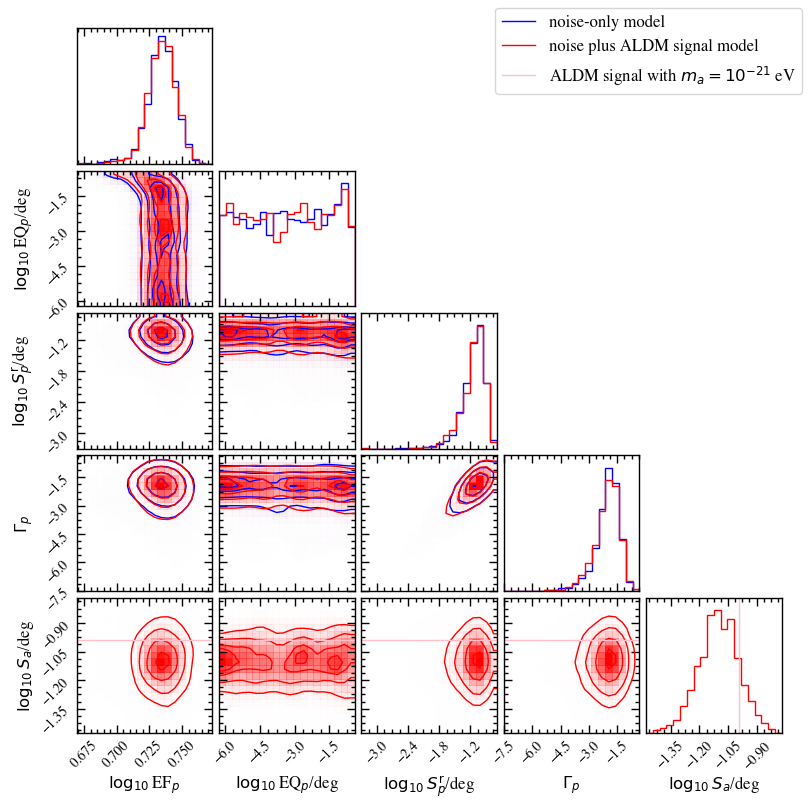

In [7]:
import corner
mpl.rcParams['lines.linewidth'] = 1
mpl.rcParams['patch.linewidth'] = 1
mpl.rcParams['xtick.labelsize']=10
mpl.rcParams['ytick.labelsize']=10
mpl.rcParams['font.size'] = 12
mpl.rcParams['axes.labelsize'] = 12
chain = np.loadtxt('aldm_chain_-21.txt',skiprows=200)
chain_red = np.loadtxt('noaldm_chain_-21_72.txt',skiprows=200)[:4000]

#chain0 = chain[chain[:,0]<0,1:-4]
chain0 = chain_red[chain_red[:,0]<0,1:-4]
chain1 = chain[chain[:,0]>0,1:-4]
print(chain0.shape)
print(chain1.shape)


fig = plt.figure(figsize=(8,8))


ipsr = 0
c0 = chain0[:1775,[ipsr , ipsr + 22 , ipsr + 22*2 , ipsr + 22*3 ,-1] ]
c1 = chain1[:1775,[ipsr , ipsr + 22 , ipsr + 22*2 , ipsr + 22*3 ,-1] ]
c0[:,1] = c0[:,1] + np.log10(180/np.pi)
c0[:,2] = c0[:,2] + np.log10(180/np.pi)
c0[:,-1] = c0[:,-1] + np.log10(180/np.pi)

c1[:,1] = c1[:,1] + np.log10(180/np.pi)
c1[:,2] = c1[:,2] + np.log10(180/np.pi)
c1[:,-1] = c1[:,-1] + np.log10(180/np.pi)

# allranges_0 = np.array([[col.min(), col.max()] for col in c0.T])
# allranges_1 = np.array([[col.min(), col.max()] for col in c1.T])
# allranges = [ (min(allranges_0[i][0], allranges_1[i][0]), max(allranges_0[i][1], allranges_1[i][1])) for i in range(len(allranges_0)) ]
# allranges[0] = [allranges[0][0],0.80]

# allranges[4] = allranges_1[4]

allranges = np.array([[col.min(), col.max()] for col in c1.T])
corner.corner(c0,range=allranges,fig=fig,smooth=1,lw=1,color='blue',plot_datapoints=False)

fig=corner.corner(c1,range=allranges,color='red',fig=fig,smooth=1,\
                  labels=[r"$\log_{10}$EF$_p$",r"$\log_{10}$EQ$_p$/deg",r"$\log_{10}S^{\rm r}_p$/deg",r"$\Gamma_p$",r"$\log_{10}S_a$/deg"],\
                  truths=[None,None,None,None,-0.99],truth_color='pink',plot_datapoints=False);


for ax in fig.axes[-5:]:
    for i,coll in enumerate(ax.collections):
        if type(coll) == matplotlib.contour.QuadContourSet:
            if coll.colors=='blue':
                coll.remove()
        if i ==1:
            coll.remove()
        #elif type(coll) == matplotlib.collections.PolyQuadMesh:
        #    coll.remove()
    for pa in ax.patches:
        if pa.get_facecolor()==(0,0,1,0):
            pa.remove()
    for pa in ax.lines:
        if pa.get_color()==(0,0,1,0):
            pa.remove()


from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color="blue", label="noise-only model"),
    Line2D([0], [0], color="red", label="noise plus ALDM signal model"),
Line2D([0], [0], color="pink", label="ALDM signal with $m_a=10^{-21}$ eV"),]

fig.legend(handles=legend_handles, loc="upper right")


plt.subplots_adjust(hspace=0.05,wspace=0.05)
#plt.suptitle(r"ALDM injection with $m_a = 10^{-21}$eV, $S_a=10^{-0.99}$deg"+"\n"+r"{\color{red}Noise-only model for J0437-4715}")
for i in [6,12,18]:
    ax = fig.axes[i]
    fig.axes[i].set_ylim(0,ax.dataLim.height*1.1)
#plt.tight_layout()
plt.savefig("mock_data_corner.pdf",bbox_inches="tight")
